[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DavidNaranjo1237/NATICUSdroid/blob/main/notebooks/05_umap_5_3_colab.ipynb)

# 5.3 Extraccion de caracteristicas no lineal con UMAP

Este notebook es autocontenido para la seccion 5.3 de la guia: selecciona el numero de componentes con UMAP y evalua nuevamente los 2 mejores modelos de la seccion 4.

Comparamos **Random Forest** y **MLP (red neuronal multicapa)**, que son los dos mejores segun las metricas obtenidas.

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip -q install umap-learn scikit-learn pandas numpy matplotlib

In [11]:
from pathlib import Path
import os
import subprocess
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import umap

warnings.filterwarnings(
    'ignore',
    message='n_jobs value 1 overridden to 1 by setting random_state.*',
    category=UserWarning,
    module='umap.umap_'
)
warnings.filterwarnings(
    'ignore',
    message='Spectral initialisation failed!.*',
    category=UserWarning,
    module='umap.spectral'
 )

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

REPO_URL = 'https://github.com/DavidNaranjo1237/NATICUSdroid.git'
REPO_DIR = Path('/content/NATICUSdroid')

def is_colab() -> bool:
    return 'COLAB_RELEASE_TAG' in os.environ or 'google.colab' in sys.modules

def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src' / 'prepare_data.py').exists():
            return candidate
    return REPO_DIR if is_colab() else Path.cwd()

repo_root = find_repo_root()
if is_colab() and not (repo_root / 'src' / 'prepare_data.py').exists():
    if not repo_root.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(repo_root)], check=True)
    else:
        print(f'Repository directory already exists at {repo_root}.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.prepare_data import prepare_dataset

print(f'Repository root: {repo_root}')
print('Entorno listo para preprocesado y UMAP.')

Repository root: c:\Users\EXITOPC\Desktop\Modelos2
Entorno listo para preprocesado y UMAP.


In [ ]:
# Preprocesado
results = prepare_dataset()
summary = results['summary']
artifacts = results['artifacts']
X_train_full = results['X_train']
X_test = results['X_test']
y_train_full = results['y_train']
y_test = results['y_test']

print('Artefactos generados:')
for name, value in artifacts.items():
    print(f'{name}: {value}')

print('')
print('Shapes:')
print('  X_train_full:', X_train_full.shape)
print('  X_test      :', X_test.shape)
print('  y_train_full:', y_train_full.shape)
print('  y_test      :', y_test.shape)
print('  #variables originales:', X_train_full.shape[1])

print('')
print('Resumen de clases:')
print(summary['class_distribution'])

Artefactos generados:
train_features: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\X_train.csv
test_features: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\X_test.csv
train_target: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\y_train.csv
test_target: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\y_test.csv
train_full: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\train.csv
test_full: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\test.csv
metadata: C:\Users\EXITOPC\Desktop\Modelos2\data\processed\split_metadata.json

Shapes:
  X_train_full: (20532, 86)
  X_test      : (8800, 86)
  y_train_full: (20532,)
  y_test      : (8800,)
  #variables originales: 86

Resumen de clases:
{'0': 14632, '1': 14700}


## Configuracion del experimento

Criterio de seleccion de componentes: se escoge el menor $k$ cuyo F1 promedio en validacion esta a maximo 0.005 del mejor valor observado, balanceando desempeño y reducción.

In [ ]:
BEST_MODELS = ['rf', 'mlp']
CANDIDATE_COMPONENTS = [2, 4, 6, 8, 10, 12]
UMAP_KWARGS = {
    'n_neighbors': 15,
    'min_dist': 0.10,
    'metric': 'euclidean',
    'random_state': RANDOM_STATE,
}

MODEL_ZOO = {
    'rf': RandomForestClassifier(
        n_estimators=200,
        max_depth=25,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'mlp': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-5,
        batch_size=128,
        learning_rate_init=0.001,
        max_iter=250,
        early_stopping=True,
        n_iter_no_change=15,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
    ),
}

for m in BEST_MODELS:
    if m not in MODEL_ZOO:
        raise ValueError(f'Modelo no soportado: {m}. Opciones: {list(MODEL_ZOO.keys())}')

def compute_metrics(y_true, y_pred, y_score):
    y_score = np.nan_to_num(np.asarray(y_score, dtype=float), nan=0.5, posinf=1.0, neginf=0.0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'specificity': specificity,
        'roc_auc': roc_auc_score(y_true, y_score),
    }

def fit_transform_umap(X_train_df, X_eval_df, n_components):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_df)
    X_eval_scaled = scaler.transform(X_eval_df)
    reducer = umap.UMAP(n_components=n_components, **UMAP_KWARGS)
    X_train_umap = np.nan_to_num(reducer.fit_transform(X_train_scaled), nan=0.0, posinf=0.0, neginf=0.0)
    X_eval_umap = np.nan_to_num(reducer.transform(X_eval_scaled), nan=0.0, posinf=0.0, neginf=0.0)
    return X_train_umap, X_eval_umap, scaler, reducer

def train_and_eval(model_key, X_tr, y_tr, X_ev, y_ev):
    model = clone(MODEL_ZOO[model_key])
    if model_key == 'mlp':
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_ev = scaler.transform(X_ev)

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_ev)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_ev)[:, 1]
    else:
        scores = model.decision_function(X_ev)
        y_score = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)

    return model, compute_metrics(y_ev, y_pred, y_score)

print('Configuracion lista. Modelos a evaluar:', BEST_MODELS)

Configuracion lista. Modelos a evaluar: ['rf', 'mlp']


c:\Users\EXITOPC\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\EXITOPC\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\EXITOPC\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\EXITOPC\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\EXITOPC\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\

Tabla de seleccion (validacion)
 n_components reduction_% rf_val_f1 mlp_val_f1 avg_val_f1
            2       97.67    0.8817     0.8121     0.8469
            4       95.35    0.8868     0.8695     0.8782
            6       93.02    0.8946     0.8870     0.8908
            8       90.70    0.8970     0.8838     0.8904
           10       88.37    0.8975     0.8842     0.8908
           12       86.05    0.8883     0.8866     0.8875

k seleccionado: 10
Reduccion alcanzada: 88.37%


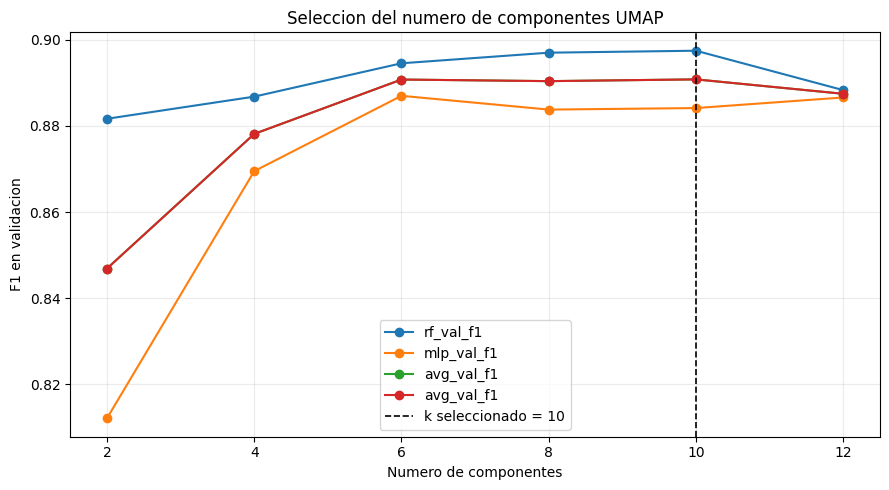

In [ ]:
# 1) Seleccion de numero de componentes con un subconjunto estratificado.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

pool_size = min(6000, len(X_train))
X_pool, _, y_pool, _ = train_test_split(
    X_train, y_train,
    train_size=pool_size,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_sel_train, X_sel_val, y_sel_train, y_sel_val = train_test_split(
    X_pool, y_pool,
    test_size=0.20,
    stratify=y_pool,
    random_state=RANDOM_STATE,
)

rows = []
for k in CANDIDATE_COMPONENTS:
    X_tr_umap, X_val_umap, _, _ = fit_transform_umap(X_sel_train, X_sel_val, k)

    f1_by_model = {}
    for model_key in BEST_MODELS:
        _, m = train_and_eval(model_key, X_tr_umap, y_sel_train, X_val_umap, y_sel_val)
        f1_by_model[f'{model_key}_val_f1'] = m['f1']

    rows.append({
        'n_components': k,
        'reduction_%': (1 - k / X_train_full.shape[1]) * 100,
        **f1_by_model,
        'avg_val_f1': np.mean(list(f1_by_model.values())),
    })

selection_df = pd.DataFrame(rows).sort_values('n_components').reset_index(drop=True)
best_avg = selection_df['avg_val_f1'].max()
selected_k = int(
    selection_df[selection_df['avg_val_f1'] >= best_avg - 0.005]
    .sort_values(['avg_val_f1', 'n_components'], ascending=[False, True])
    .iloc[0]['n_components']
)
reduction_pct = (1 - selected_k / X_train_full.shape[1]) * 100

print('Tabla de seleccion (validacion)')
print(selection_df.to_string(index=False, formatters={
    'reduction_%': '{:.2f}'.format,
    'avg_val_f1': '{:.4f}'.format,
    **{c: '{:.4f}'.format for c in selection_df.columns if c.endswith('_val_f1')}
}))
print('')
print(f'k seleccionado: {selected_k}')
print(f'Reduccion alcanzada: {reduction_pct:.2f}%')

plot_cols = [c for c in selection_df.columns if c.endswith('_val_f1') and c != 'avg_val_f1'] + ['avg_val_f1']
ax = selection_df.plot(x='n_components', y=plot_cols, marker='o', figsize=(9, 5))
ax.axvline(selected_k, color='black', linestyle='--', linewidth=1.2, label=f'k seleccionado = {selected_k}')
ax.set_title('Seleccion del numero de componentes UMAP')
ax.set_xlabel('Numero de componentes')
ax.set_ylabel('F1 en validacion')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 2) Entrenamiento final con todo train y evaluacion en test.
X_train_umap, X_test_umap, _, _ = fit_transform_umap(X_train_full, X_test, selected_k)

final_rows = []
for model_key in BEST_MODELS:
    model, train_metrics = train_and_eval(model_key, X_train_umap, y_train_full, X_train_umap, y_train_full)

    if model_key == 'mlp':
        scaler = StandardScaler()
        X_tr_eval = scaler.fit_transform(X_train_umap)
        X_te_eval = scaler.transform(X_test_umap)
        y_test_pred = model.predict(X_te_eval)
        y_test_score = model.predict_proba(X_te_eval)[:, 1]
    else:
        y_test_pred = model.predict(X_test_umap)
        y_test_score = model.predict_proba(X_test_umap)[:, 1]

    test_metrics = compute_metrics(y_test, y_test_pred, y_test_score)

    model_name = 'Random Forest' if model_key == 'rf' else 'Red neuronal multicapa'
    final_rows.append({'Modelo': model_name, 'Split': 'Train', 'n_components': selected_k, 'reduction_%': reduction_pct, **train_metrics})
    final_rows.append({'Modelo': model_name, 'Split': 'Test',  'n_components': selected_k, 'reduction_%': reduction_pct, **test_metrics})

final_table = pd.DataFrame(final_rows)[[
    'Modelo', 'Split', 'n_components', 'reduction_%',
    'accuracy', 'precision', 'recall', 'f1', 'specificity', 'roc_auc'
]]

print('Resultados finales UMAP (listo para reporte)')
print(final_table.to_string(index=False, formatters={
    'reduction_%': '{:.2f}'.format,
    'accuracy': '{:.4f}'.format,
    'precision': '{:.4f}'.format,
    'recall': '{:.4f}'.format,
    'f1': '{:.4f}'.format,
    'specificity': '{:.4f}'.format,
    'roc_auc': '{:.4f}'.format,
}))

# Guardado de resultados
output_dir = repo_root / 'Informe_latex' / 'figuras'
if IN_COLAB and not output_dir.exists():
    output_dir = Path('/content/umap_outputs')
output_dir.mkdir(parents=True, exist_ok=True)

selection_df.to_csv(output_dir / 'umap_seleccion.csv', index=False)
final_table.to_csv(output_dir / 'umap_resultados.csv', index=False)

print('')
print('Archivos guardados en:', output_dir.resolve())
print(' - umap_seleccion.csv')
print(' - umap_resultados.csv')

c:\Users\EXITOPC\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Resultados finales UMAP (listo para reporte)
                Modelo Split  n_components reduction_% accuracy precision recall     f1 specificity roc_auc
         Random Forest Train            10       88.37   1.0000    1.0000 1.0000 1.0000      1.0000  1.0000
         Random Forest  Test            10       88.37   0.9169    0.9150 0.9197 0.9173      0.9141  0.9588
Red neuronal multicapa Train            10       88.37   0.9411    0.9542 0.9270 0.9404      0.9553  0.9820
Red neuronal multicapa  Test            10       88.37   0.9136    0.9270 0.8984 0.9125      0.9289  0.9603

Archivos guardados en: C:\Users\EXITOPC\Desktop\Modelos2\notebooks\Informe_latex\figuras
 - umap_seleccion.csv
 - umap_resultados.csv
